# Fine-tune BERT & Qwen → So sánh với REIC

Notebook này:
1. Load ontology và tạo training data
2. Fine-tune **BERT** (bert-base-uncased) với classification head
3. Fine-tune **Qwen** (Qwen2-1.5B) với sequence classification head
4. So sánh REIC vs BERT-FT vs Qwen-FT trên test queries

## 1. Setup & Load data

**Nếu tải model bị gián đoạn (KeyboardInterrupt):** Chỉ cần **chạy lại cell** — Hugging Face sẽ tiếp tục tải từ chỗ dở (resume). Hoặc đổi sang `DistilBERT` (nhỏ hơn, ~70MB) trong cell dưới.

In [1]:
import sys
import json
from pathlib import Path

# Add project root
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from reic.ontology import IntentOntology

DATA_DIR = ROOT / "data"
CHECKPOINT_DIR = ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

ontology_path = DATA_DIR / "ontology.json"
ontology = IntentOntology.from_json(ontology_path)
intents = list(ontology.iter_leaf_intents())
print(f"Số intent: {len(intents)}")

def load_train_data():
    data = []
    for intent in ontology.iter_leaf_intents():
        for ex in intent.examples:
            data.append((ex.strip(), intent.id))
    return data

train_data = load_train_data()
print(f"Training samples: {len(train_data)}")
for i, (text, lid) in enumerate(train_data[:6]):
    print(f"  {i+1}. {text[:50]}... → {lid}")

Số intent: 8
Training samples: 24
  1. I want to change my address... → change_shipping_address
  2. Update my shipping address... → change_shipping_address
  3. Tôi muốn đổi địa chỉ giao hàng... → change_shipping_address
  4. Thay đổi địa chỉ nhận hàng... → change_shipping_address
  5. Where is my package?... → delivery_status
  6. Track my order... → delivery_status


## 2. Fine-tune BERT (classification head)

In [2]:
# Tắt Xet download → tải bằng HTTP, resume tốt hơn khi bị gián đoạn
import os
from pathlib import Path
os.environ["HF_HUB_DISABLE_XET"] = "1"
# Load .env (HF_TOKEN) nếu có
try:
    from dotenv import load_dotenv
    load_dotenv(Path.cwd().parent / ".env" if Path.cwd().name == "notebooks" else Path.cwd() / ".env")
except Exception:
    pass
print("OK: HF_HUB_DISABLE_XET=1. Chạy cell dưới để tải model (nếu bị ngắt, chạy lại cell đó).")

OK: HF_HUB_DISABLE_XET=1. Chạy cell dưới để tải model (nếu bị ngắt, chạy lại cell đó).


In [3]:
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)
from torch.utils.data import Dataset
import torch

# distilbert (~70MB) hoặc bert-base-uncased (~440MB). Tải bị gián đoạn → chạy lại cell (resume).
BERT_MODEL = "distilbert-base-uncased"
BERT_CKPT = CHECKPOINT_DIR / "bert"

# Label map
intent_ids = sorted(set(t[1] for t in train_data))
id2idx = {i: idx for idx, i in enumerate(intent_ids)}
num_labels = len(intent_ids)

class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt",
        )
        self.labels = [id2idx[l] for l in labels]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return {
            "input_ids": self.encodings["input_ids"][i],
            "attention_mask": self.encodings["attention_mask"][i],
            "labels": torch.tensor(self.labels[i], dtype=torch.long),
        }

tokenizer_bert = AutoTokenizer.from_pretrained(BERT_MODEL)
model_bert = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL, num_labels=num_labels
)

texts = [t[0] for t in train_data]
labels = [t[1] for t in train_data]
dataset_bert = IntentDataset(texts, labels, tokenizer_bert)

args_bert = TrainingArguments(
    output_dir=str(BERT_CKPT),
    num_train_epochs=5,
    per_device_train_batch_size=8,
    save_strategy="no",
    logging_steps=5,
)
trainer_bert = Trainer(
    model=model_bert,
    args=args_bert,
    train_dataset=dataset_bert,
)
trainer_bert.train()
trainer_bert.save_model(str(BERT_CKPT))
tokenizer_bert.save_pretrained(str(BERT_CKPT))

with open(BERT_CKPT / "label_map.json", "w") as f:
    json.dump({"id2idx": id2idx, "idx2id": {v: k for k, v in id2idx.items()}}, f)

print(f"BERT fine-tuned → {BERT_CKPT}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/Users/huynguyen/Documents/research/intent classification/REIC/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory

Step,Training Loss
5,2.068161
10,1.988641
15,1.913231


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT fine-tuned → /Users/huynguyen/Documents/research/intent classification/REIC/checkpoints/bert


## 3. Fine-tune Qwen (sequence classification head)

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch.nn as nn

QWEN_MODEL = "Qwen/Qwen2-1.5B-Instruct"
QWEN_CKPT = CHECKPOINT_DIR / "qwen"
QWEN_CKPT.mkdir(parents=True, exist_ok=True)

tokenizer_qwen = AutoTokenizer.from_pretrained(QWEN_MODEL, trust_remote_code=True)
base_qwen = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL,
    dtype=torch.float32,
    trust_remote_code=True,
)

# Freeze base, chỉ train classification head
for p in base_qwen.parameters():
    p.requires_grad = False

hidden_size = base_qwen.config.hidden_size
encoder = base_qwen.model if hasattr(base_qwen, "model") else base_qwen.transformer
classifier_head = nn.Linear(hidden_size, num_labels)
optimizer = torch.optim.AdamW(classifier_head.parameters(), lr=1e-3)

EPOCHS = 3
BATCH_SIZE = 4

for epoch in range(EPOCHS):
    total_loss = 0.0
    n_batches = 0
    for i in range(0, len(train_data), BATCH_SIZE):
        batch = train_data[i : i + BATCH_SIZE]
        batch_texts = [t[0] for t in batch]
        batch_labels = [id2idx[t[1]] for t in batch]

        inputs = tokenizer_qwen(
            batch_texts,
            return_tensors="pt",
            truncation=True,
            max_length=128,
            padding=True,
        )
        with torch.no_grad():
            out = encoder(**inputs)
        last_hidden = out.last_hidden_state[:, -1, :]
        logits = classifier_head(last_hidden)
        loss = nn.functional.cross_entropy(
            logits, torch.tensor(batch_labels, dtype=torch.long)
        )
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    print(f"Epoch {epoch+1}/{EPOCHS} loss: {total_loss/n_batches:.4f}")

torch.save(classifier_head.state_dict(), QWEN_CKPT / "classifier.pt")
tokenizer_qwen.save_pretrained(str(QWEN_CKPT))
base_qwen.save_pretrained(str(QWEN_CKPT))
with open(QWEN_CKPT / "label_map.json", "w") as f:
    json.dump({"id2idx": id2idx, "idx2id": {v: k for k, v in id2idx.items()}}, f)

print(f"Qwen fine-tuned → {QWEN_CKPT}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Epoch 1/3 loss: 5.9698
Epoch 2/3 loss: 0.5605
Epoch 3/3 loss: 0.1047


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Qwen fine-tuned → /Users/huynguyen/Documents/research/intent classification/REIC/checkpoints/qwen


## 4. Load models & Test queries

In [5]:
# Test queries: (query, expected_intent_id)
TEST_QUERIES = [
    ("Update my shipping address", "change_shipping_address"),
    ("I want to change my address", "change_shipping_address"),
    ("Where is my package?", "delivery_status"),
    ("Tôi muốn trả hàng", "return_order"),
    ("I want to return this item", "return_order"),
    ("Leave at doorstep", "shipping_instructions"),
    ("Máy Kindle bị treo màn hình", "kindle_reset"),
    ("Alexa won't connect to wifi", "alexa_wifi"),
    ("Renew my streaming subscription", "subscription_renewal"),
]

In [6]:
from reic.pipeline import ReicPipeline
from reic.baselines.roberta_classifier import RoBERTaClassifier
from reic.baselines.llm_classifier import LLMClassifier

# REIC (không cần train)
pipeline_reic = ReicPipeline(ROOT / "data" / "ontology.json", top_k=5, backend="tfidf")

# BERT fine-tuned (dùng checkpoint từ bước 2 - bert-base tương đương RoBERTa classifier)
# Nếu dùng BERT thay RoBERTa: cần wrapper tương tự RoBERTaClassifier cho bert-base
from reic.baselines.roberta_classifier import RoBERTaClassifier

bert_clf = RoBERTaClassifier(
    model_name=BERT_MODEL,
    checkpoint_path=BERT_CKPT if BERT_CKPT.exists() else None,
)
bert_clf.fit(intents)

# Qwen fine-tuned
qwen_clf = LLMClassifier(
    model_name=QWEN_MODEL,
    checkpoint_path=QWEN_CKPT if QWEN_CKPT.exists() else None,
)
qwen_clf.fit(intents)

print("REIC, BERT-FT, Qwen-FT loaded.")

REIC, BERT-FT, Qwen-FT loaded.


## 5. So sánh REIC vs BERT-FT vs Qwen-FT

In [7]:
def run_reic(q):
    r = pipeline_reic.predict(q)
    return r.intent_id, r.confidence

def run_bert(q):
    iid, _, conf, _ = bert_clf.predict(q)
    return iid, conf

def run_qwen(q):
    iid, _, conf, _ = qwen_clf.predict(q)
    return iid, conf

methods = {
    "REIC": run_reic,
    "BERT-FT": run_bert,
    "Qwen-FT": run_qwen,
}

results = {}
for name, fn in methods.items():
    correct = sum(1 for q, exp in TEST_QUERIES if fn(q)[0] == exp)
    total = len(TEST_QUERIES)
    results[name] = {"correct": correct, "total": total, "accuracy": correct / total}
    print(f"{name:10} | Acc: {correct/total:.1%} ({correct}/{total})")

print("\nChi tiết từng query:")
print("-" * 70)
for query, expected in TEST_QUERIES:
    print(f"Query: {query}")
    print(f"  Expected: {expected}")
    for name, fn in methods.items():
        pred, conf = fn(query)
        ok = "✓" if pred == expected else "✗"
        print(f"  {name:10} → {pred} (conf: {conf:.2f}) {ok}")
    print()

REIC       | Acc: 100.0% (9/9)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

BERT-FT    | Acc: 11.1% (1/9)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen-FT    | Acc: 0.0% (0/9)

Chi tiết từng query:
----------------------------------------------------------------------
Query: Update my shipping address
  Expected: change_shipping_address
  REIC       → change_shipping_address (conf: 0.99) ✓
  BERT-FT    → delivery_status (conf: 0.19) ✗
  Qwen-FT    → return_order (conf: 0.83) ✗

Query: I want to change my address
  Expected: change_shipping_address
  REIC       → change_shipping_address (conf: 0.98) ✓
  BERT-FT    → delivery_status (conf: 0.16) ✗
  Qwen-FT    → return_order (conf: 0.47) ✗

Query: Where is my package?
  Expected: delivery_status
  REIC       → delivery_status (conf: 0.99) ✓
  BERT-FT    → return_order (conf: 0.18) ✗
  Qwen-FT    → return_order (conf: 0.98) ✗

Query: Tôi muốn trả hàng
  Expected: return_order
  REIC       → return_order (conf: 0.97) ✓
  BERT-FT    → delivery_status (conf: 0.16) ✗
  Qwen-FT    → kindle_reset (conf: 1.00) ✗

Query: I want to return this item
  Expected: return_order
  REIC       → ret

In [8]:
import pandas as pd

df = pd.DataFrame({
    "Method": list(results.keys()),
    "Accuracy": [results[k]["accuracy"] for k in results],
    "Correct": [results[k]["correct"] for k in results],
    "Total": [results[k]["total"] for k in results],
})
df

,Method,Accuracy,Correct,Total
0,REIC,1.000000,9,9
1,BERT-FT,0.111111,1,9
2,Qwen-FT,0.000000,0,9


## 6. Biểu đồ so sánh

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Chuẩn bị dữ liệu cho biểu đồ (chạy cell so sánh trước)
df_plot = pd.DataFrame({
    "Method": list(results.keys()),
    "Accuracy": [results[k]["accuracy"] for k in results],
    "Correct": [results[k]["correct"] for k in results],
    "Total": [results[k]["total"] for k in results],
})

# Màu
colors = ["#2ecc71", "#3498db", "#9b59b6"]

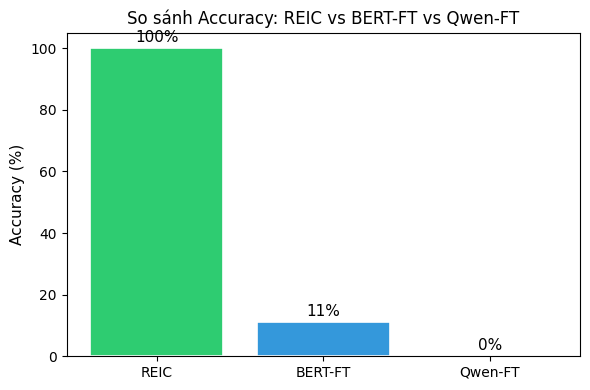

In [10]:
# 1. Biểu đồ cột: Accuracy (%) theo từng method
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(df_plot["Method"], df_plot["Accuracy"] * 100, color=colors, edgecolor="white", linewidth=1.2)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_title("So sánh Accuracy: REIC vs BERT-FT vs Qwen-FT", fontsize=12)
ax.set_ylim(0, 105)
for bar, acc in zip(bars, df_plot["Accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2, f"{acc*100:.0f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

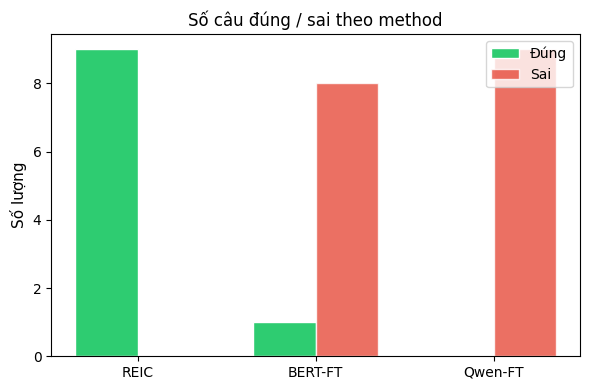

In [11]:
# 2. Biểu đồ cột nhóm: Correct vs Total (số câu đúng / tổng)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(df_plot["Method"]))
w = 0.35
ax.bar(x - w/2, df_plot["Correct"], w, label="Đúng", color="#2ecc71", edgecolor="white")
ax.bar(x + w/2, df_plot["Total"] - df_plot["Correct"], w, label="Sai", color="#e74c3c", alpha=0.8, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(df_plot["Method"])
ax.set_ylabel("Số lượng", fontsize=11)
ax.set_title("Số câu đúng / sai theo method", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

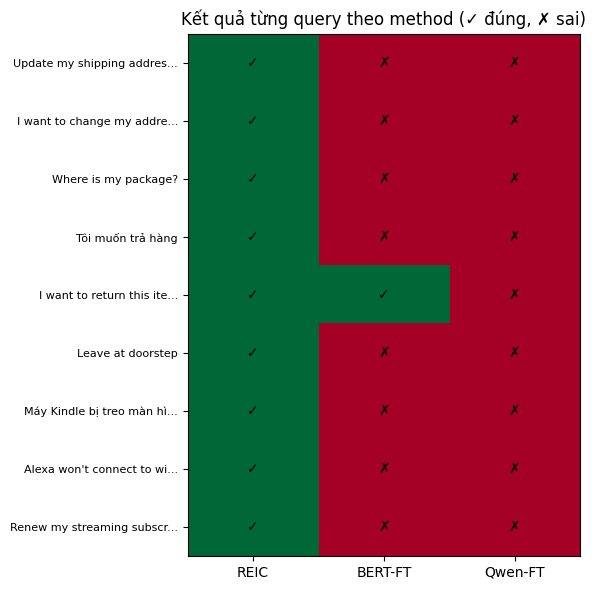

In [12]:
# 3. Heatmap: từng query × method (1 = đúng, 0 = sai)
matrix = []
for query, expected in TEST_QUERIES:
    row = []
    for name, fn in methods.items():
        pred, _ = fn(query)
        row.append(1 if pred == expected else 0)
    matrix.append(row)

matrix = np.array(matrix)
method_names = list(methods.keys())
query_labels = [q[:25] + "..." if len(q) > 25 else q for q, _ in TEST_QUERIES]

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(matrix, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(np.arange(len(method_names)))
ax.set_yticks(np.arange(len(query_labels)))
ax.set_xticklabels(method_names)
ax.set_yticklabels(query_labels, fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
for i in range(len(query_labels)):
    for j in range(len(method_names)):
        text = "✓" if matrix[i, j] == 1 else "✗"
        ax.text(j, i, text, ha="center", va="center", color="black", fontsize=10)
ax.set_title("Kết quả từng query theo method (✓ đúng, ✗ sai)", fontsize=12)
plt.tight_layout()
plt.show()

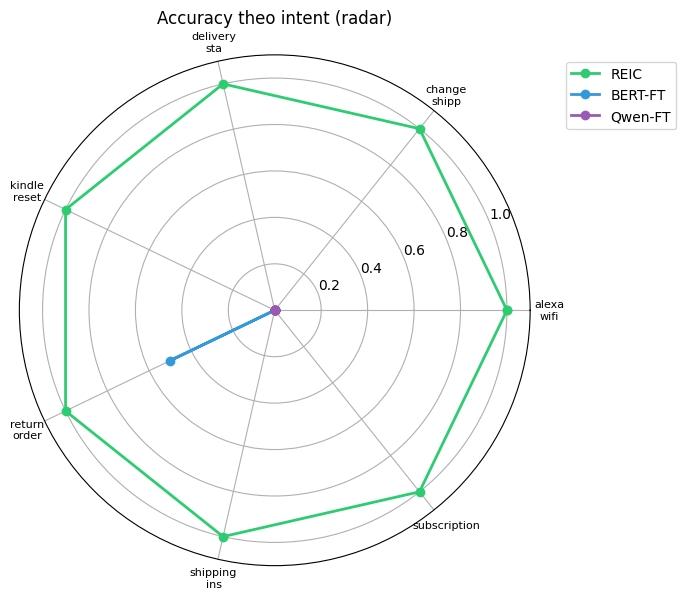

In [13]:
# 4. Biểu đồ radar (spider): so sánh theo từng intent
from collections import defaultdict
intent_results = defaultdict(lambda: {m: {"correct": 0, "total": 0} for m in methods})
for query, expected in TEST_QUERIES:
    for name, fn in methods.items():
        pred, _ = fn(query)
        intent_results[expected][name]["total"] += 1
        if pred == expected:
            intent_results[expected][name]["correct"] += 1

intent_ids = sorted(intent_results.keys())
angles = np.linspace(0, 2 * np.pi, len(intent_ids), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(projection="polar"))
for (method, color) in zip(method_names, colors):
    accs = []
    for iid in intent_ids:
        r = intent_results[iid][method]
        acc = r["correct"] / r["total"] if r["total"] else 0
        accs.append(acc)
    accs = accs + accs[:1]
    ax.plot(angles, accs, "o-", linewidth=2, label=method, color=color)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([iid.replace("_", "\n")[:12] for iid in intent_ids], fontsize=8)
ax.set_ylim(0, 1.1)
ax.set_title("Accuracy theo intent (radar)", fontsize=12)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()